# Updates
- 20260920 - V1: 
    - Initial testing of different models and operationability
    - "Make dataset" filters for delivered orders only - Not feasible for actual run because we won't know the actual status on any particular run date
- 20260926 - V2: 
    - Update "Make dataset" to align with actual operations
        - Only pull pXd training data and implement label completeness checks
    - Implement monthly inference backtesting
- 20261004 - V4:
    - Finalised notebook structure: Model dev pipeline -> CV + Hyperparam tuning -> Select best model
- 20201004 - V5:
    - Utilise helper functions to make dataset which includes extra features used in regression

# Environment Set-up

In [1]:
# Install dependencies (uncomment if running in Colab)
# %pip install -q pandas numpy matplotlib seaborn plotly scikit-learn xgboost lightgbm

import json, os, sys, warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, os.path.abspath('.') if os.path.isdir('src') else os.path.abspath('phase2'))

import os
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Machine Learning
import xgboost as xgb
from sklearn.tree import DecisionTreeClassifier
from lightgbm import LGBMClassifier
from sklearn.impute import SimpleImputer
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, average_precision_score
)

from src.tuning import FoldWeightedPipeline
from src.preprocessing import make_preprocessor
from src import RANDOM_STATE, LOOKBACK, PXD
from src.data import load_olist_data
from src.features import (build_feature_table, add_extra_features,
                          NUM_COLS, CAT_COLS, EXTRA_NUM_COLS, LEAKAGE_COLS)

# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

print(f"pandas: {pd.__version__}")
print(f"numpy: {np.__version__}")

pandas: 2.1.4
numpy: 1.26.4


# Constants

In [2]:
NUM_COLS = NUM_COLS + EXTRA_NUM_COLS
FEATURE_COLS = NUM_COLS + CAT_COLS
print(f"Number of features: {len(FEATURE_COLS)}")
print(f"Number of numeric features: {len(NUM_COLS)}")
print(f"Number of categorical features: {len(CAT_COLS)}")
LABEL_COL = 'dpt_var_late_delivery'

Number of features: 41
Number of numeric features: 39
Number of categorical features: 2


# Load data and create features
- Use helper functions to load data
- Final dataframe containing all relevant columns provided by the various source tables, the partition month and date (from `order_approved_at`)
- The dependent variable of whether an order is late is determined in the next section
- Not all columns in this table will be used as features as this table only serves as a historical dataset of all orders and their attributes for audit tracking purposes when this pipeline is productionised
- Feature selection will be performed in a later section to ensure no data leakage
    - e.g. Columns like durn_to_customer_days, durn_to_carrier_days will be dropped

In [3]:
olist = load_olist_data()
orders = olist['orders']
final_df = add_extra_features(build_feature_table(olist), olist)
print(f'Shape: {final_df.shape}; unique orders: {final_df["order_id"].nunique():,}')

Loaded orders: 99,441 rows × 8 cols
Loaded order_items: 112,650 rows × 7 cols
Loaded customers: 99,441 rows × 5 cols
Loaded products: 32,951 rows × 9 cols
Loaded sellers: 3,095 rows × 4 cols
Loaded payments: 103,886 rows × 5 cols
Loaded reviews: 99,224 rows × 7 cols
Loaded geolocation: 1,000,163 rows × 5 cols
Loaded category_translation: 71 rows × 2 cols
Shape: (98959, 61); unique orders: 98,959


## Inspect data

In [4]:
null_counts = final_df.isna().sum()
display(null_counts[null_counts > 0].sort_values(ascending=False))

print(f"Shape: {final_df.shape}")
print(f"Unique order_id: {final_df['order_id'].nunique()}")
print(final_df.shape)

display(final_df.head())

durn_to_customer_days            2769
order_delivered_customer_date    2769
order_product_photos_mean        2005
order_delivered_carrier_date     1596
durn_to_carrier_days             1596
seller_dist_km_max               1108
seller_dist_km_min               1108
seller_dist_km_median            1108
seller_dist_km_mean              1108
order_product_volume_cm3_sum      635
seller_city_count                 619
seller_state                      619
seller_city                       619
seller_zip_code_prefix            619
product_category_name             619
seller_state_count                619
order_revenue_sum                 619
seller_zip_code_prefix_count      619
order_product_category_count      619
order_product_weight_g_sum        619
order_frieght_value_sum           619
order_pdt_price_sum               619
order_seller_count                619
order_item_count                  619
seller_dist_km_count              619
freight_to_price_ratio            619
dtype: int64

Shape: (98959, 61)
Unique order_id: 98959
(98959, 61)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_approved_dt,order_approved_day_of_week,order_approved_day_of_month,order_approved_month,order_approved_week_of_year,partition_yyyymm,durn_to_carrier_days,durn_to_customer_days,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,route_type,seller_dist_km_max,seller_dist_km_min,seller_dist_km_median,seller_dist_km_mean,...,product_category_name,seller_zip_code_prefix,seller_city,seller_state,payment_value_sum,payment_type_value_boleto,payment_type_value_credit_card,payment_type_value_debit_card,payment_type_value_not_defined,payment_type_value_voucher,payment_type_count_boleto,payment_type_count_credit_card,payment_type_count_debit_card,payment_type_count_not_defined,payment_type_count_voucher,promised_lead_days,approval_lag_hours,order_product_volume_cm3_sum,order_product_photos_mean,payment_installments_max,freight_to_price_ratio,is_weekend_approval,is_black_friday_period,is_december_peak,orders_approved_prev_7d
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017-10-02,1,2,10,40,2017-10,2.37,8.43,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,2. All same-state,18.68,18.68,18.68,18.68,...,{housewares},{9350},{maua},{SP},38.71,0.00,18.12,0.00,0.00,20.59,0.00,1.00,0.00,0.00,2.00,16,0.18,1976.00,4.00,1,0.29,0,0,0,951.00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018-07-26,4,26,7,30,2018-07,0.46,12.50,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1. All interstate,861.04,861.04,861.04,861.04,...,{perfumery},{31570},{belo horizonte},{SP},141.46,141.46,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,18,30.71,4693.00,1.00,1,0.19,0,0,0,1694.00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018-08-08,3,8,8,32,2018-08,0.20,9.38,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1. All interstate,514.55,514.55,514.55,514.55,...,{auto},{14840},{guariba},{SP},179.12,0.00,179.12,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,27,0.28,9576.00,1.00,3,0.12,0,0,0,2216.00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,2017-11-18,6,18,11,46,2017-11,3.75,13.20,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,1. All interstate,1821.81,1821.81,1821.81,1821.81,...,{pet_shop},{31842},{belo horizonte},{MG},72.20,0.00,72.20,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,27,0.30,6000.00,3.00,1,0.60,1,0,0,1316.00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2018-02-13,2,13,2,7,2018-02,0.89,2.83,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,2. All same-state,29.59,29.59,29.59,29.59,...,{stationery},{8752},{mogi das cruzes},{SP},28.62,0.00,28.62,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,13,1.03,11475.00,4.00,1,0.44,0,0,0,1566.00


# Label definition

- This section is used to determine a suitable lookback buffer period at time of the model run date to ensure sufficient label availability based on the delivery outcomes that are known on the model run date itself.
- Here, we want to have at least 99% availability of the order labels

**Outcomes definitions:**

| Outcome as of model run date | Label |
|---|---|
| Delivered on or before the promised delivery day | **0 - On time** |
| Delivered after the promised delivery day | **1 - Late** |
| Still undelivered and the promised delivery day has fully passed | **1 - Late** |
| Still undelivered and the promised delivery day has not fully passed | **Unknown - Excluded from training** |

A delivery dated on or after the model run date is treated as not yet observed. 
- All comparisons use calendar dates
- Missing or invalid required dates leave the label unknown
- For simplicity, we assume that the promised delivery day remains on time until the following midnight


**Unknown labels have two subcategories:**

1. `unresolved`: the order is still undelivered through the day before the run date, and its estimated delivery day has not fully passed
2. `invalid_or_missing_dates`: required dates are missing or inconsistent, so a reliable label cannot be assigned. These orders are counted in `invalid_dates`

Both subcategories retain a missing `label_as_of_run`: **unknown_labels = unresolved orders + invalid_dates**.

For example, suppose the model runs on **June 2, 2018 (using data through June 1)**:

| Approval date | Estimated delivery date | Actual delivery date in the dataset | Subcategory | Why the label is unknown at the run time |
|---|---|---|---|---|
| May 2, 2018 | June 6, 2018 | June 4, 2018 | `unresolved` | Delivery is still in the future at the run time, and the deadline has not passed. |
| May 2, 2018 | June 2, 2018 | Missing | `unresolved` | The order still has the remainder of June 2 to arrive on time. |
| May 2, 2018 | Missing | May 21, 2018 | `invalid_or_missing_dates` | The order was delivered, but its estimated date is missing, so lateness cannot be determined. |
| May 6, 2018 | May 21, 2018 | May 4, 2018 | `invalid_or_missing_dates` | Delivery appears to precede approval, indicating inconsistent dates. |

In contrast, an order estimated for **June 1, 2018** that is still undelivered at this run time will be assigned with a **known label of 1 (late)**, assuming its required dates are valid because its promised delivery day has fully passed

## Check buffer lengths at each model training date
- Review label availability at historical run times
- Assumes delivery events are recorded immediately and available by end of the day at 2359H
- Unknown labels include invalid/missing dates which must be excluded from training

In [5]:
BUFFER_RUN_DATES = ['2018-04-01', '2018-05-01', '2018-06-01']
BUFFER_DAYS = [15, 30, 45, 60]
BUFFER_WINDOW_DAYS = PXD
BUFFER_COMPLETENESS_TARGET = 99.0  # To set an acceptable threshold

label_orders = orders.loc[
        orders['order_id'].isin(final_df['order_id']),
        ['order_id', 'order_approved_at', 'order_delivered_customer_date', 'order_estimated_delivery_date']
    ].drop_duplicates('order_id').copy()
for col in label_orders.columns.drop('order_id'):
    label_orders[col] = pd.to_datetime(label_orders[col])
label_orders['order_approved_dt'] = label_orders['order_approved_at'].dt.normalize()


def labels_as_of(order_rows, run_date: str):
    """Assign labels using calendar dates strictly before run_date (YYYY-MM-DD)."""

    if not isinstance(run_date, str):
        raise ValueError('run_date must be a YYYY-MM-DD string')
    run_day = pd.to_datetime(run_date, format='%Y-%m-%d', errors='coerce')
    
    result = order_rows.copy()

    # Obtain Series based on required dates
    approved = pd.to_datetime(result['order_approved_at']).dt.normalize()
    delivered = pd.to_datetime(result['order_delivered_customer_date']).dt.normalize()
    deadline = pd.to_datetime(result['order_estimated_delivery_date']).dt.normalize()

    # Define orders
    valid = approved.notna() & approved.lt(run_day) & deadline.notna()
    invalid_delivery = delivered.notna() & delivered.lt(approved) # Flag delivery dates before approval dates
    valid &= ~invalid_delivery
    delivered_by_run = delivered.notna() & delivered.lt(run_day)
    overdue = deadline.lt(run_day)

    result['delivered_by_run'] = delivered_by_run
    result['label_as_of_run'] = pd.Series(pd.NA, index=result.index, dtype='Int64')
    result['label_status'] = 'unresolved'
    result.loc[~valid, 'label_status'] = 'invalid_or_missing_dates'
    on_time = valid & delivered_by_run & delivered.le(deadline)
    late_delivered = valid & delivered_by_run & delivered.gt(deadline)
    late_undelivered = valid & ~delivered_by_run & overdue
    result.loc[on_time, 'label_as_of_run'] = 0
    result.loc[late_delivered | late_undelivered, 'label_as_of_run'] = 1
    result.loc[on_time, 'label_status'] = 'on_time_delivered'
    result.loc[late_delivered, 'label_status'] = 'late_delivered'
    result.loc[late_undelivered, 'label_status'] = 'late_undelivered' # Run date already exceeded estimated delivery date and not delivered yet
    return result


buffer_rows = []
buffer_label_audits = {}  # Inspect an individual run/buffer's order-level labels.
for run_date in BUFFER_RUN_DATES:
    run_day = pd.Timestamp(run_date).normalize()
    inference_date = run_day - pd.Timedelta(days=1)
    as_of = labels_as_of(label_orders, run_date=run_date)
    for buffer_days in BUFFER_DAYS:
        end_date = inference_date - pd.Timedelta(days=buffer_days)
        start_date = end_date - pd.Timedelta(days=BUFFER_WINDOW_DAYS - 1)
        window = as_of.loc[as_of['order_approved_dt'].between(start_date, end_date)].copy()
        buffer_label_audits[(run_date, buffer_days)] = window
        for scope, scope_start in [
            ('full_window', start_date),
            ('newest_7_days', max(start_date, end_date - pd.Timedelta(days=6)))
        ]:
            cohort = window.loc[window['order_approved_dt'].ge(scope_start)]
            total = len(cohort)
            known = int(cohort['label_as_of_run'].notna().sum())
            completeness = 100 * known / total if total else float('nan')
            buffer_rows.append({
                'run_date': run_day, 
                'buffer_days': buffer_days,
                'scope': scope, 
                'start_date': scope_start, 
                'end_date': end_date,
                'orders': total, 
                'known_labels': known,
                'unknown_labels': total - known,
                'on_time_delivered': int(cohort['label_status'].eq('on_time_delivered').sum()),
                'late_delivered': int(cohort['label_status'].eq('late_delivered').sum()),
                'late_undelivered': int(cohort['label_status'].eq('late_undelivered').sum()),
                'total_late_delivery_rate_pct': 100 * cohort['label_as_of_run'].eq(1).sum() / known if known else float('nan'),
                'delivered_by_run_pct': 100 * cohort['delivered_by_run'].sum() / total if total else float('nan'),
                'label_completeness_pct': completeness,
                'meets_target': bool(total and completeness >= BUFFER_COMPLETENESS_TARGET)
            })
buffer_review = pd.DataFrame(buffer_rows)

for scope in ['full_window', 'newest_7_days']:
    print(f'\n{scope}:')
    display(buffer_review.loc[buffer_review['scope'].eq(scope)].round(2))

buffer_summary = buffer_review.groupby('buffer_days', as_index=False).agg(
    worst_completeness_pct=('label_completeness_pct', 'min'),
    all_runs_and_scopes_meet_target=('meets_target', 'all')
)
display(buffer_summary.round(2))

# Final evaluation of buffer period
passing_buffers = buffer_summary.loc[buffer_summary['all_runs_and_scopes_meet_target'], 'buffer_days']
if passing_buffers.empty:
    print(f'No candidate meets {BUFFER_COMPLETENESS_TARGET}% in every run and scope.')
else:
    print(f'Smallest candidate meeting {BUFFER_COMPLETENESS_TARGET}% in every run and scope: '
          f'{passing_buffers.min()} days. Note that this is only historical evidence and not a future guarantee.')


full_window:


,run_date,buffer_days,scope,start_date,end_date,orders,known_labels,unknown_labels,on_time_delivered,late_delivered,late_undelivered,total_late_delivery_rate_pct,delivered_by_run_pct,label_completeness_pct,meets_target
0,2018-04-01,15,full_window,2017-03-17,2018-03-16,58794,57910,884,52025,3471,2414,10.16,94.41,98.50,False
2,2018-04-01,30,full_window,2017-03-02,2018-03-01,56583,56543,40,50999,3388,2156,9.80,96.14,99.93,True
4,2018-04-01,45,full_window,2017-02-15,2018-02-14,53426,53413,13,48600,2985,1828,9.01,96.58,99.98,True
6,2018-04-01,60,full_window,2017-01-31,2018-01-30,51249,51239,10,46653,2794,1792,8.95,96.50,99.98,True
8,2018-05-01,15,full_window,2017-04-16,2018-04-15,63151,62791,360,55978,4696,2117,10.85,96.10,99.43,True
10,2018-05-01,30,full_window,2017-04-01,2018-03-31,60940,60895,45,54122,4704,2069,11.12,96.55,99.93,True
12,2018-05-01,45,full_window,2017-03-17,2018-03-16,58794,58778,16,52387,4458,1933,10.87,96.70,99.97,True
14,2018-05-01,60,full_window,2017-03-02,2018-03-01,56583,56571,12,51013,3706,1852,9.82,96.73,99.98,True
16,2018-06-01,15,full_window,2017-05-17,2018-05-16,68174,67637,537,60624,4966,2047,10.37,96.23,99.21,True
18,2018-06-01,30,full_window,2017-05-02,2018-05-01,65658,65619,39,58630,4992,1997,10.65,96.92,99.94,True



newest_7_days:


,run_date,buffer_days,scope,start_date,end_date,orders,known_labels,unknown_labels,on_time_delivered,late_delivered,late_undelivered,total_late_delivery_rate_pct,delivered_by_run_pct,label_completeness_pct,meets_target
1,2018-04-01,15,newest_7_days,2018-03-10,2018-03-16,1588,986,602,912,19,55,7.51,58.63,62.09,False
3,2018-04-01,30,newest_7_days,2018-02-23,2018-03-01,1837,1809,28,1363,187,259,24.65,84.38,98.48,False
5,2018-04-01,45,newest_7_days,2018-02-08,2018-02-14,1403,1402,1,1219,130,53,13.05,96.15,99.93,True
7,2018-04-01,60,newest_7_days,2018-01-24,2018-01-30,1530,1530,0,1359,118,53,11.18,96.54,100.00,True
9,2018-05-01,15,newest_7_days,2018-04-09,2018-04-15,1561,1330,231,1313,4,13,1.28,84.37,85.20,False
11,2018-05-01,30,newest_7_days,2018-03-25,2018-03-31,1437,1414,23,1231,90,93,12.94,91.93,98.40,False
13,2018-05-01,45,newest_7_days,2018-03-10,2018-03-16,1588,1586,2,1179,318,89,25.66,94.27,99.87,True
15,2018-05-01,60,newest_7_days,2018-02-23,2018-03-01,1837,1836,1,1377,396,63,25.00,96.52,99.95,True
17,2018-06-01,15,newest_7_days,2018-05-10,2018-05-16,2025,1630,395,1567,10,53,3.87,77.88,80.49,False
19,2018-06-01,30,newest_7_days,2018-04-25,2018-05-01,1635,1614,21,1538,27,49,4.71,95.72,98.72,False


,buffer_days,worst_completeness_pct,all_runs_and_scopes_meet_target
0,15,62.09,False
1,30,98.40,False
2,45,99.87,True
3,60,99.95,True


Smallest candidate meeting 99.0% in every run and scope: 45 days. Note that this is only historical evidence and not a future guarantee.


# Get training data
- To operationalise this pipeline, we need to run predictions on a daily basis, for example:
    - The prediction job is set to run at 0030H daily
    - Assuming at 2018-06-02 0030H, the orders approved on 2018-06-01 would have all came in. We want to predict whether the orders approved on 2018-06-01 will be late.
    - To do so, we look at the last delivered orders from 45 days ago which is the lookback buffer period we have determined earlier to ensure label availability.
        - Run date: 2018-06-02
        - Inference date: 2018-06-01 (we are predicting for orders approved on this date)
        - Train-test period: 2017-10-20 to 2018-04-17 based on lookback buffer period of 45 days and pXd of 180 days
    - pXd simply serve as the duration of train-test data (how much train & test data we want to use)

In [6]:
def get_required_dates(run_date: str, lookback: int = 45, pXd: int = 180):
    """Return (start, end, inference_date) as YYYY-MM-DD strings; window is inclusive."""
    if isinstance(pXd, bool) or not isinstance(pXd, int) or pXd <= 0:
        raise ValueError('pXd must be a positive integer')
    if isinstance(lookback, bool) or not isinstance(lookback, int) or lookback < 0:
        raise ValueError('lookback must be a non-negative integer')

    if not isinstance(run_date, str):
        raise ValueError('run_date must be a YYYY-MM-DD string')
    run_day = pd.to_datetime(run_date, format='%Y-%m-%d', errors='coerce')
    if pd.isna(run_day) or run_day.strftime('%Y-%m-%d') != run_date:
        raise ValueError('run_date must be a valid date in YYYY-MM-DD format')
    inference_date = run_day - pd.Timedelta(days=1)

    test_end_date = inference_date - pd.Timedelta(days=lookback)
    test_start_date = test_end_date - pd.Timedelta(days=30-1)
    train_end_date = test_start_date - pd.Timedelta(days=1)
    train_start_date = train_end_date - pd.Timedelta(days=pXd-30-1)

    inference_date_str = inference_date.strftime('%Y-%m-%d')
    test_end_date = test_end_date.strftime('%Y-%m-%d')
    test_start_date = test_start_date.strftime('%Y-%m-%d')
    train_end_date = train_end_date.strftime('%Y-%m-%d')
    train_start_date = train_start_date.strftime('%Y-%m-%d')

    print(f"Train-test period for the inference date of {inference_date_str} with buffer of {lookback} days and pXd of {pXd} days:")
    print(f"   Train period: {train_start_date} to {train_end_date} ({pXd-30} days)")
    print(f"   Test period: {test_start_date} to {test_end_date} (30 days)")

    return train_start_date, train_end_date, test_start_date, test_end_date, inference_date_str

run_date = '2018-06-02'
train_start_date, train_end_date, test_start_date, test_end_date, inference_date = get_required_dates(run_date, lookback=LOOKBACK, pXd=PXD)

Train-test period for the inference date of 2018-06-01 with buffer of 45 days and pXd of 365 days:
   Train period: 2017-04-18 to 2018-03-18 (335 days)
   Test period: 2018-03-19 to 2018-04-17 (30 days)


In [7]:
train_test_df = final_df[
    final_df['order_approved_dt'].between(
        train_start_date,
        test_end_date,
        inclusive='both'
    )
].copy()
train_test_df['order_approved_dt'].value_counts().sort_index()

order_approved_dt
2017-04-18     87
2017-04-19     82
2017-04-20     93
2017-04-21     78
2017-04-22     70
             ... 
2018-04-13    337
2018-04-14    173
2018-04-15    180
2018-04-16    224
2018-04-17    319
Name: count, Length: 365, dtype: int64

## Check label availability
- This section serves as a label availability check during each training run in production
- It does not filter rows or replace existing targets yet
- Use label_as_of_run from the audit for binary training labels at this run timestamp

In [8]:
# Use dates before run_date; the operational 00:30 schedule has no effect.
LABEL_AVAILABILITY_TARGET_PCT = 99.0

# Count each order once and retain the order-level audit for inspection.
train_test_label_audit = labels_as_of(train_test_df.drop_duplicates('order_id'), run_date=run_date)

total_orders = len(train_test_label_audit)
known_labels = int(train_test_label_audit['label_as_of_run'].notna().sum())
unknown_labels = total_orders - known_labels
unresolved_labels = int(train_test_label_audit['label_status'].eq('unresolved').sum())
invalid_dates = int(train_test_label_audit['label_status'].eq('invalid_or_missing_dates').sum())
label_availability_pct = 100 * known_labels / total_orders if total_orders else float('nan')

print(f'Model run on {run_date}:')
print(f'Training/test approvals: {train_start_date} to {test_end_date} '
      f'({PXD} days; {LOOKBACK}-day buffer)')
if total_orders:
    print(f'Labels available: {known_labels:,}/{total_orders:,} ({label_availability_pct:.2f}%)')
    print(f'Unknown labels: {unknown_labels:,} '
          f'(unresolved: {unresolved_labels:,}; invalid/missing dates: {invalid_dates:,})')
    if label_availability_pct >= LABEL_AVAILABILITY_TARGET_PCT:
        print(f'PASS: label availability meets the {LABEL_AVAILABILITY_TARGET_PCT:g}% target.')
    else:
        print(f'WARNING: label availability is below the {LABEL_AVAILABILITY_TARGET_PCT:g}% target.')
    if unknown_labels:
        print('Exclude unknown labels from supervised training, even when the availability target is met.')
else:
    print('WARNING: no orders in the selected training/test period; label availability cannot be calculated.')

Model run on 2018-06-02:
Training/test approvals: 2017-04-18 to 2018-04-17 (365 days; 45-day buffer)
Labels available: 63,592/63,605 (99.98%)
Unknown labels: 13 (unresolved: 2; invalid/missing dates: 11)
PASS: label availability meets the 99% target.
Exclude unknown labels from supervised training, even when the availability target is met.


## Determine late delivery labels
- Refer to label definition above
- Unknown outcomes are excluded

In [9]:
# Retain only orders with a known label at the model run date.
train_test_label = train_test_label_audit.loc[
    train_test_label_audit['label_as_of_run'].notna()
].copy()

# Use the audited binary target, including overdue undelivered orders.
train_test_label[LABEL_COL] = train_test_label['label_as_of_run'].astype(int)

print(f'Removed {len(train_test_label_audit) - len(train_test_label):,} orders with unknown labels.')
print(f'Retained {len(train_test_label):,} orders with known labels.')
display(train_test_label['label_status'].value_counts())
display(train_test_label[LABEL_COL].value_counts(normalize=True))

Removed 13 orders with unknown labels.
Retained 63,592 orders with known labels.


label_status
on_time_delivered    56629
late_delivered        5015
late_undelivered      1948
Name: count, dtype: int64

dpt_var_late_delivery
0   0.89
1   0.11
Name: proportion, dtype: float64

## Train test split
- Train-test split is done chronologically to simulate a production pipeline where the orders in the latest 30 days of the train-test period will serve as the test set and the orders before that will be the train set
- Check class imbalance

In [10]:
train_df = train_test_label[
    train_test_label['order_approved_dt'].between(
        train_start_date,
        train_end_date,
        inclusive='both'
    )
].copy()

train_df = train_df.sort_values('order_approved_dt', kind='stable')
X_train, y_train = train_df[FEATURE_COLS], train_df[LABEL_COL]

test_df = train_test_label[
    train_test_label['order_approved_dt'].between(
        test_start_date,
        test_end_date,
        inclusive='both'
    )
].copy()
X_test, y_test = test_df[FEATURE_COLS], test_df[LABEL_COL]

print(f"\nData split complete:")
print(f"   Training: {len(X_train):,} samples ({y_train.mean()*100:.2f}% late)")
print(f"   Test:     {len(X_test):,} samples ({y_test.mean()*100:.2f}% late)")


Data split complete:
   Training: 56,722 samples (11.02% late)
   Test:     6,870 samples (10.38% late)


# Preprocessor
- Missing numeric values are handled inside each model pipeline using training medians for Logistic Regression, Decision Tree, XGBoost, Random Forest and LightGBM.

In [11]:
# Fit numeric medians and category mappings on training data inside each pipeline.
preprocessor = make_preprocessor(NUM_COLS, CAT_COLS)

# Model Training
- Instantiate the model pipelines and train the models

## Logistic Regression

In [12]:
# Baseline with class balancing; preprocessing is fitted on training data only.
lr_preprocessor = make_preprocessor(NUM_COLS, CAT_COLS, scale=True)
lr_pipeline = Pipeline([
    ('preprocessor', lr_preprocessor),
    ('classifier', LogisticRegression(
        class_weight='balanced', max_iter=1000, random_state=42,
    )),
])
lr_pipeline.fit(X_train, y_train)
print('Logistic Regression Pipeline trained!')

Logistic Regression Pipeline trained!


## Decision Tree

In [13]:
# Limit tree depth and balance classes for the late-delivery target.
dt_pipeline = Pipeline([
    ('preprocessor', clone(preprocessor)),
    ('classifier', DecisionTreeClassifier(
        max_depth=10,
        class_weight='balanced',
        random_state=42,
    )),
])
dt_pipeline.fit(X_train, y_train)
print('Decision Tree Pipeline trained!')

Decision Tree Pipeline trained!


## Random Forest

In [14]:
rf_classifier = RandomForestClassifier(
    n_estimators=100,           # Number of trees in the forest
    max_depth=10,               # Maximum tree depth
    class_weight='balanced',    # Auto-adjust weights inversely to class freq
    random_state=42,
    n_jobs=-1                   # Use all CPU cores for parallel training
)

# Create Pipeline with a fresh preprocessor
# (Each pipeline needs its own preprocessor to avoid conflicts)
rf_pipeline = Pipeline([
    ('preprocessor', clone(preprocessor)),
    ('classifier', rf_classifier)
])

# Fit the entire pipeline
rf_pipeline.fit(X_train, y_train)
print("   Random Forest Pipeline trained!")
print("   Pipeline steps: preprocessor -> classifier")

   Random Forest Pipeline trained!
   Pipeline steps: preprocessor -> classifier


## XGBoost

In [15]:
xgb_classifier = xgb.XGBClassifier(
    n_estimators=100,           # Number of boosting rounds (trees)
    max_depth=6,                # Maximum tree depth (controls complexity)
    learning_rate=0.1,          # Step size shrinkage (prevents overfitting)

    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

# Create Pipeline: preprocessor -> model
xgb_pipeline = FoldWeightedPipeline([
    ('preprocessor', preprocessor),
    ('classifier', xgb_classifier)
])

# Fit the entire pipeline (preprocessor + model) on training data
xgb_pipeline.fit(X_train, y_train)
print("   XGBoost Pipeline trained!")
print("   Pipeline steps: preprocessor -> classifier")

   XGBoost Pipeline trained!
   Pipeline steps: preprocessor -> classifier


## LightGBM

In [16]:
lgb_pipeline = FoldWeightedPipeline([
    ('preprocessor', clone(preprocessor)),
    ('classifier', LGBMClassifier(

        random_state=42, 
        verbosity=-1,
        n_jobs=-1,
    )),
])
lgb_pipeline.fit(X_train, y_train)
print('LightGBM Pipeline trained!')

LightGBM Pipeline trained!


# Evaluation - Test Set

In [17]:
def evaluate_pipeline(pipeline, X_test, y_test):
    """
    Evaluate a pipeline and return metrics.

    Note: X_test contains RAW features (not preprocessed).
    The pipeline handles preprocessing internally.
    """
    # Pipeline handles preprocessing + prediction in one call
    y_pred = pipeline.predict(X_test)              # Binary: 0 or 1
    y_prob = pipeline.predict_proba(X_test)[:, 1]  # Probability of late delivery

    metrics = {
        'roc_auc': (roc_auc_score(y_test, y_prob)
                    if pd.Series(y_test).nunique() == 2 else np.nan),
        'pr_auc': (average_precision_score(y_test, y_prob)
                    if pd.Series(y_test).nunique() == 2 else np.nan),
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'f1_score': f1_score(y_test, y_pred, zero_division=0),
        }

    return metrics, y_pred, y_prob

# Evaluate pipelines (note: X_test is RAW data, pipeline handles preprocessing)
lr_metrics, lr_pred, lr_prob = evaluate_pipeline(lr_pipeline, X_test, y_test)
dt_metrics, dt_pred, dt_prob = evaluate_pipeline(dt_pipeline, X_test, y_test)
rf_metrics, rf_pred, rf_prob = evaluate_pipeline(rf_pipeline, X_test, y_test)
xgb_metrics, xgb_pred, xgb_prob = evaluate_pipeline(xgb_pipeline, X_test, y_test)
lgb_metrics, lgb_pred, lgb_prob = evaluate_pipeline(lgb_pipeline, X_test, y_test)

print(f"Baseline precision: {y_test.mean():.2%}")

metrics_summary = pd.DataFrame({
    'Logistic Regression': lr_metrics,
    'Decision Tree': dt_metrics,
    'Random Forest': rf_metrics,
    'XGBoost': xgb_metrics,
    'LightGBM': lgb_metrics,
}).T
display((metrics_summary * 100).style.format("{:.2f}%"))

model_scores = {
    'Logistic Regression': lr_prob,
    'Decision Tree': dt_prob,
    'Random Forest': rf_prob,
    'XGBoost': xgb_prob,
    'LightGBM': lgb_prob,
}

Baseline precision: 10.38%


,roc_auc,pr_auc,accuracy,precision,recall,f1_score
Logistic Regression,73.20%,26.39%,52.26%,15.51%,80.93%,26.03%
Decision Tree,68.13%,19.10%,39.08%,13.13%,86.68%,22.80%
Random Forest,73.20%,25.71%,59.26%,17.47%,78.54%,28.58%
XGBoost,73.68%,26.07%,43.64%,14.21%,87.94%,24.46%
LightGBM,73.52%,27.11%,41.15%,13.66%,87.80%,23.64%


# Feature Importances

In [19]:
# Logistic Regression: numeric features are standardized; categorical features
# remain 0/1 indicators. Coefficients describe changes in late-delivery log-odds.
lr_coefficients = lr_pipeline.named_steps['classifier'].coef_[0]
lr_top10 = (
    pd.DataFrame({
        'feature': lr_pipeline.named_steps['preprocessor'].get_feature_names_out(),
        'coefficient': lr_coefficients,
        'absolute_coefficient': np.abs(lr_coefficients),
    })
    .sort_values('absolute_coefficient', ascending=False)
    .head(10).reset_index(drop=True)
)


# Decision Tree: normalized total reduction in impurity per feature.
dt_top10 = (
    pd.DataFrame({
        'feature': dt_pipeline.named_steps['preprocessor'].get_feature_names_out(),
        'impurity_importance': dt_pipeline.named_steps['classifier'].feature_importances_
    })
    .sort_values('impurity_importance', ascending=False)
    .head(10).reset_index(drop=True)
)


rf_top10 = (
    pd.DataFrame({
        'feature': rf_pipeline.named_steps['preprocessor'].get_feature_names_out(),
        'impurity_importance': rf_pipeline.named_steps['classifier'].feature_importances_
    })
    .sort_values('impurity_importance', ascending=False)
    .head(10).reset_index(drop=True)
)


xgb_feature_names = xgb_pipeline.named_steps['preprocessor'].get_feature_names_out()
xgb_booster = xgb_pipeline.named_steps['classifier'].get_booster()
xgb_gain = xgb_booster.get_score(importance_type='gain')
xgb_feature_keys = xgb_booster.feature_names or [f'f{i}' for i in range(len(xgb_feature_names))]

xgb_top10 = (
    pd.DataFrame({
        'feature': xgb_feature_names,
        'gain': [xgb_gain.get(key, 0.0) for key in xgb_feature_keys]
    })
    .sort_values('gain', ascending=False)
    .head(10).reset_index(drop=True)
)


lgb_top10 = (
    pd.DataFrame({
        'feature': lgb_pipeline.named_steps['preprocessor'].get_feature_names_out(),
        'total_gain': lgb_pipeline.named_steps['classifier'].booster_.feature_importance(
            importance_type='gain'
        ),
    })
    .sort_values('total_gain', ascending=False)
    .head(10).reset_index(drop=True)
)


print('Logistic Regression: top 10 by absolute coefficient (positive = higher late-delivery odds)')
display(lr_top10)
print('Decision Tree: top 10 features by decrease in impurity')
display(dt_top10)
print('XGBoost: top 10 features by average gain')
display(xgb_top10)
print('Random Forest: top 10 features by mean decrease in impurity')
display(rf_top10)
print('LightGBM: top 10 by total split gain')
display(lgb_top10)

Logistic Regression: top 10 by absolute coefficient (positive = higher late-delivery odds)


,feature,coefficient,absolute_coefficient
0,numeric__order_pdt_price_sum,-5.88,5.88
1,numeric__order_revenue_sum,4.95,4.95
2,numeric__order_approved_week_of_year,-2.37,2.37
3,numeric__order_approved_month,2.10,2.10
4,categorical__customer_state_RR,1.74,1.74
5,categorical__customer_state_AL,1.10,1.10
6,categorical__customer_state_PR,-0.85,0.85
7,categorical__customer_state_MG,-0.79,0.79
8,categorical__customer_state_AP,-0.72,0.72
9,numeric__payment_value_sum,0.69,0.69


Decision Tree: top 10 features by decrease in impurity


,feature,impurity_importance
0,numeric__orders_approved_prev_7d,0.19
1,numeric__order_frieght_value_sum,0.16
2,categorical__route_type_1. All interstate,0.09
3,numeric__order_approved_week_of_year,0.07
4,numeric__promised_lead_days,0.06
5,numeric__approval_lag_hours,0.05
6,categorical__customer_state_RJ,0.05
7,numeric__order_approved_month,0.03
8,numeric__order_product_volume_cm3_sum,0.03
9,numeric__freight_to_price_ratio,0.03


XGBoost: top 10 features by average gain


,feature,gain
0,categorical__route_type_1. All interstate,1122.02
1,categorical__customer_state_RJ,212.15
2,numeric__orders_approved_prev_7d,125.28
3,categorical__route_type_2. All same-state,117.29
4,categorical__customer_state_SP,108.38
5,numeric__order_frieght_value_sum,98.78
6,numeric__seller_dist_km_mean,83.69
7,numeric__order_seller_count,79.74
8,categorical__customer_state_MG,70.57
9,numeric__order_approved_month,63.86


Random Forest: top 10 features by mean decrease in impurity


,feature,impurity_importance
0,numeric__orders_approved_prev_7d,0.11
1,numeric__order_approved_week_of_year,0.09
2,numeric__order_approved_month,0.06
3,numeric__order_frieght_value_sum,0.05
4,numeric__seller_dist_km_min,0.05
5,numeric__seller_dist_km_max,0.05
6,numeric__promised_lead_days,0.05
7,numeric__seller_dist_km_mean,0.05
8,numeric__seller_dist_km_median,0.05
9,categorical__customer_state_RJ,0.04


LightGBM: top 10 by total split gain


,feature,total_gain
0,numeric__orders_approved_prev_7d,32389.66
1,numeric__order_frieght_value_sum,25834.61
2,numeric__promised_lead_days,15841.81
3,numeric__order_approved_week_of_year,14468.55
4,numeric__order_product_volume_cm3_sum,11014.35
5,categorical__route_type_1. All interstate,9799.61
6,numeric__seller_dist_km_min,8635.58
7,categorical__customer_state_RJ,8605.64
8,numeric__order_product_weight_g_sum,8539.84
9,numeric__approval_lag_hours,8330.44


# Probability Distribution

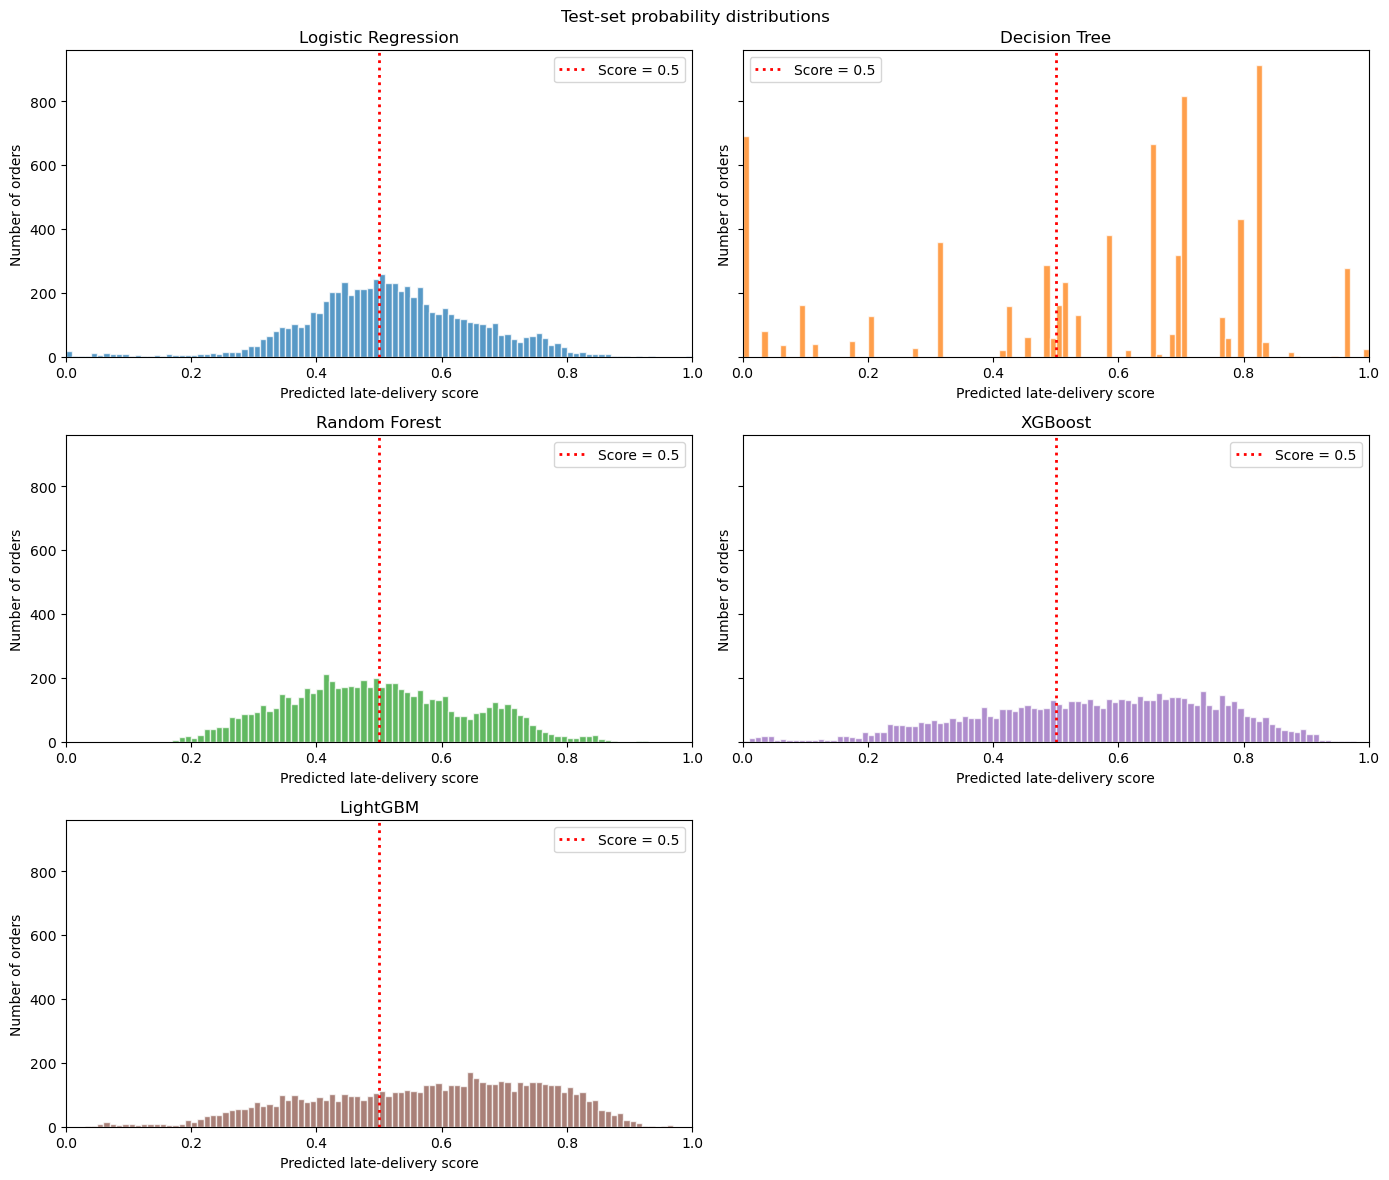

In [20]:
# Use the same bins and axis scales to compare all five models.
fig, axes = plt.subplots(3, 2, figsize=(14, 12), sharex=True, sharey=True)
bins = np.linspace(0, 1, 101)
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:purple', 'tab:brown']

for ax, (name, scores), color in zip(axes.flat, model_scores.items(), colors):
    ax.hist(scores, bins=bins, color=color, alpha=0.75, edgecolor='white')
    ax.axvline(0.5, color='red', linestyle=':', linewidth=2, label='Score = 0.5')
    ax.set_title(name)
    ax.set_xlabel('Predicted late-delivery score')
    ax.set_ylabel('Number of orders')
    ax.set_xlim(0, 1)
    ax.tick_params(labelbottom=True)
    ax.legend()

for ax in list(axes.flat)[len(model_scores):]:
    ax.set_visible(False)

fig.suptitle('Test-set probability distributions')
plt.tight_layout()
plt.show()

# Backtesting - Inference Set
- Using the trained models, peform inference on a "live" (unseen) cohort of newly approved orders
- Orders eligibility:
    - These orders are not delivered yet, they are all eligible orders approved on the inference date
- Operation:
    - Model trained on 2nd day of each month such that the inference date is the 1st
    - This model will be used to predict for all days in that month
    - The predictions on these 30/31 days will then be collated to have sufficient data to compute the evaluation metrics and coverage on a monthly basis

**Monthly evaluation and label availability**

- Pool all daily predictions for the month after every cohort has reached its own cutoff. The outcome data must cover those cutoffs.
- Compute monthly metrics using known actual labels; report unknown outcomes separately.
- The historical buffer audit supports the 45-day choice against the **99% label-availability target**. Check and report availability for the inference cohort as well.
- Training uses completed days strictly before its shared model run date. Retrospective inference evaluation includes its entire per-cohort cutoff date. Both use the same date-based label rules.

In [21]:
def get_month_start_end(run_date: str):
    """Return the first and last dates of run_date's month as YYYY-MM-DD strings."""
    from calendar import monthrange
    from datetime import date

    if not isinstance(run_date, str):
        raise ValueError('run_date must be a YYYY-MM-DD string')
    try:
        run_day = date.fromisoformat(run_date)
    except ValueError as exc:
        raise ValueError('run_date must be a valid date in YYYY-MM-DD format') from exc
    if run_day.isoformat() != run_date:
        raise ValueError('run_date must be a valid date in YYYY-MM-DD format')

    month_start = run_day.replace(day=1)
    month_end = run_day.replace(day=monthrange(run_day.year, run_day.month)[1])
    return month_start.isoformat(), month_end.isoformat()

inference_month_start_date, inference_month_end_date = get_month_start_end(run_date)
print(f'Days to run inference: {inference_month_start_date} to {inference_month_end_date}')

Days to run inference: 2018-06-01 to 2018-06-30


## Perform inference loop
- Loop over the inference days to collect all the predictions and perform evaluation

In [22]:
def run_inference(inference_month_start_date, inference_month_end_date, model_pipeline):
    """Score eligible orders over an inclusive date range using a fitted pipeline.

    Uses the notebook's final_df and FEATURE_COLS. Orders must be approved on
    the inference day and not delivered by that day. Preprocessing is not refitted.
    Returns approval date, order ID and late-delivery probability for each order.
    """
    start_day = pd.to_datetime(inference_month_start_date).normalize()
    end_day = pd.to_datetime(inference_month_end_date).normalize()
    if pd.isna(start_day) or pd.isna(end_day) or start_day > end_day:
        raise ValueError('Inference dates must be valid and start must not exceed end.')

    daily_prediction_frames = []
    late_class_index = list(model_pipeline.classes_).index(1)
    approval_days = pd.to_datetime(final_df['order_approved_dt']).dt.normalize()
    delivery_days = pd.to_datetime(final_df['order_delivered_customer_date']).dt.normalize()

    for inference_day in pd.date_range(start_day, end_day, freq='D'):
        # Only deliveries through the inference day are already observed.
        eligible = approval_days.eq(inference_day) & (
            delivery_days.isna() | delivery_days.gt(inference_day)
        )
        daily_orders = final_df.loc[eligible]
        if daily_orders.empty:
            continue

        daily_features = daily_orders[FEATURE_COLS].copy()
        daily_predictions = daily_orders[['order_approved_dt', 'order_id']].copy()
        daily_predictions['order_approved_dt'] = inference_day
        daily_predictions['predicted_probability'] = model_pipeline.predict_proba(
            daily_features
        )[:, late_class_index]
        daily_prediction_frames.append(daily_predictions)

    inference_predictions = (
        pd.concat(daily_prediction_frames, ignore_index=True)
        .sort_values(['order_approved_dt', 'order_id'], ignore_index=True)
        if daily_prediction_frames else pd.DataFrame({
            'order_approved_dt': pd.Series(dtype='datetime64[ns]'),
            'order_id': pd.Series(dtype='object'),
            'predicted_probability': pd.Series(dtype='float64'),
        })
    )
    model_name = type(model_pipeline.named_steps['classifier']).__name__
    print(f'{model_name} predictions: \n{len(inference_predictions):,} orders between '
          f'{start_day:%Y-%m-%d} and {end_day:%Y-%m-%d} (inclusive), across '
          f'{inference_predictions["order_approved_dt"].nunique()} days with eligible orders\n')
    return inference_predictions


lr_inference_predictions = run_inference(inference_month_start_date, inference_month_end_date, lr_pipeline)
dt_inference_predictions = run_inference(inference_month_start_date, inference_month_end_date, dt_pipeline)
rf_inference_predictions = run_inference(inference_month_start_date, inference_month_end_date, rf_pipeline)
xgb_inference_predictions = run_inference(inference_month_start_date, inference_month_end_date, xgb_pipeline)
lgb_inference_predictions = run_inference(inference_month_start_date, inference_month_end_date, lgb_pipeline)

# Sample model: inspect predicted probabilities for LGBM model
display(lgb_inference_predictions)

LogisticRegression predictions: 
6,164 orders between 2018-06-01 and 2018-06-30 (inclusive), across 30 days with eligible orders

DecisionTreeClassifier predictions: 
6,164 orders between 2018-06-01 and 2018-06-30 (inclusive), across 30 days with eligible orders

RandomForestClassifier predictions: 
6,164 orders between 2018-06-01 and 2018-06-30 (inclusive), across 30 days with eligible orders

XGBClassifier predictions: 
6,164 orders between 2018-06-01 and 2018-06-30 (inclusive), across 30 days with eligible orders

LGBMClassifier predictions: 
6,164 orders between 2018-06-01 and 2018-06-30 (inclusive), across 30 days with eligible orders



,order_approved_dt,order_id,predicted_probability
0,2018-06-01,00c763284c0056eed753352f5559ff0a,0.21
1,2018-06-01,022d4b171a04520ca2113a48b6b61380,0.24
2,2018-06-01,025a548c7e6d70e6b6cf600a112b0d9c,0.20
3,2018-06-01,038b8c914a94247880b6a34413e74a34,0.17
4,2018-06-01,05bdb94211a1ae1e3734545262f50da3,0.19
...,...,...,...
6159,2018-06-30,f41726f3a7dc9654767a9c5f80089ddd,0.40
6160,2018-06-30,f4ce5abb3bd4aac9e9c5f5685604cbcb,0.74
6161,2018-06-30,f7943f103569d2bb8a79fe584fcd07e5,0.51
6162,2018-06-30,f7dcd88b218022d33734106bf56e3165,0.77


### Attach actual and predicted labels

**Target and predicted labels**

- Target: **failed to arrive by the promised delivery date**.
- Predicted label **1 (late)**: model score is greater than or equal to `PREDICTION_THRESHOLD` (0.5).
- Predicted label **0 (on time)**: model score is below 0.5.
- Daily predictions use the same fitted monthly model; attaching actual labels later does not change the saved scores

In [23]:
PREDICTION_THRESHOLD = 0.5

def attach_prediction_labels(predictions, lookback=LOOKBACK,
                             prediction_threshold=PREDICTION_THRESHOLD, *,
                             model_name='Model'):
    """Return a labelled copy of predictions using inclusive approval-day cutoffs.

    Requires order_id and predicted_probability columns. Uses the notebook's
    orders table and labels_as_of helper. Reports the count and percentage of
    known actual labels at approval day + lookback for the supplied model.
    The prediction threshold defaults to PREDICTION_THRESHOLD (0.5).
    """
    if isinstance(lookback, bool) or not isinstance(lookback, int) or lookback < 0:
        raise ValueError('lookback must be a non-negative integer')
    labelled_predictions = predictions.copy()
    # Inclusive cutoff date: observe the whole approval day + lookback days.
    # Reuse the training label rules, with a separate cutoff for each daily cohort.
    outcomes = orders[['order_id', 'order_approved_at', 'order_delivered_customer_date',
                       'order_estimated_delivery_date']].drop_duplicates('order_id').copy()
    outcomes = outcomes.loc[outcomes['order_id'].isin(labelled_predictions['order_id'])].copy()

    for column in ['order_approved_at', 'order_delivered_customer_date',
                   'order_estimated_delivery_date']:
        outcomes[column] = pd.to_datetime(outcomes[column])
    
    outcomes['evaluation_cutoff'] = (outcomes['order_approved_at'].dt.normalize() + pd.Timedelta(days=lookback))
    outcomes['actual_label'] = pd.Series(pd.NA, index=outcomes.index, dtype='Int64')
    outcomes['label_status'] = 'invalid_or_missing_dates'
    for cutoff, cohort in outcomes.groupby('evaluation_cutoff'):
        # The helper excludes its run date; use the next day to include the full cutoff day.
        audit_day = cutoff + pd.Timedelta(days=1)
        audit = labels_as_of(cohort, run_date=audit_day.strftime('%Y-%m-%d'))
        outcomes.loc[audit.index, 'actual_label'] = audit['label_as_of_run']
        outcomes.loc[audit.index, 'label_status'] = audit['label_status']

    # Map by order ID so rerunning does not duplicate rows or columns.
    outcome_lookup = outcomes.set_index('order_id')
    for column in ['actual_label', 'label_status', 'evaluation_cutoff']:
        labelled_predictions[column] = (
            labelled_predictions['order_id'].map(outcome_lookup[column])
        )
    labelled_predictions['actual_label'] = (labelled_predictions['actual_label'].astype('Int64'))
    labelled_predictions['predicted_label'] = (labelled_predictions['predicted_probability'] >= prediction_threshold).astype(int)

    known_labels = int(labelled_predictions['actual_label'].notna().sum())
    total_predictions = len(labelled_predictions)
    label_completeness_pct = ((known_labels / total_predictions * 100) if total_predictions else np.nan)
    availability_pct = f'{label_completeness_pct:.2f}%' if total_predictions else 'N/A'
    print(f'{model_name}: known actual labels at approval day + {lookback} days: '
          f'{known_labels:,}/{total_predictions:,} ({availability_pct})')
    if total_predictions:
        availability_result = (
            'PASS' if label_completeness_pct >= BUFFER_COMPLETENESS_TARGET else 'WARNING'
        )
        print(f'{availability_result}: inference label availability versus '
              f'{BUFFER_COMPLETENESS_TARGET:g}% historical target.')

    return labelled_predictions


lr_inference_predictions = attach_prediction_labels(lr_inference_predictions, model_name='Logistic Regression')
dt_inference_predictions = attach_prediction_labels(dt_inference_predictions, model_name='Decision Tree')
rf_inference_predictions = attach_prediction_labels(rf_inference_predictions, model_name='Random Forest')
xgb_inference_predictions = attach_prediction_labels(xgb_inference_predictions, model_name='XGBoost')
lgb_inference_predictions = attach_prediction_labels(lgb_inference_predictions, model_name='LightGBM')

# Sample model: inspect label-status counts and the labelled prediction table.
display(lgb_inference_predictions['label_status'].value_counts(dropna=False))
display(lgb_inference_predictions)

Logistic Regression: known actual labels at approval day + 45 days: 6,155/6,164 (99.85%)
PASS: inference label availability versus 99% historical target.
Decision Tree: known actual labels at approval day + 45 days: 6,155/6,164 (99.85%)
PASS: inference label availability versus 99% historical target.
Random Forest: known actual labels at approval day + 45 days: 6,155/6,164 (99.85%)
PASS: inference label availability versus 99% historical target.
XGBoost: known actual labels at approval day + 45 days: 6,155/6,164 (99.85%)
PASS: inference label availability versus 99% historical target.
LightGBM: known actual labels at approval day + 45 days: 6,155/6,164 (99.85%)
PASS: inference label availability versus 99% historical target.


label_status
on_time_delivered    6018
late_undelivered       87
late_delivered         50
unresolved              9
Name: count, dtype: int64

,order_approved_dt,order_id,predicted_probability,actual_label,label_status,evaluation_cutoff,predicted_label
0,2018-06-01,00c763284c0056eed753352f5559ff0a,0.21,0,on_time_delivered,2018-07-16,0
1,2018-06-01,022d4b171a04520ca2113a48b6b61380,0.24,0,on_time_delivered,2018-07-16,0
2,2018-06-01,025a548c7e6d70e6b6cf600a112b0d9c,0.20,0,on_time_delivered,2018-07-16,0
3,2018-06-01,038b8c914a94247880b6a34413e74a34,0.17,0,on_time_delivered,2018-07-16,0
4,2018-06-01,05bdb94211a1ae1e3734545262f50da3,0.19,0,on_time_delivered,2018-07-16,0
...,...,...,...,...,...,...,...
6159,2018-06-30,f41726f3a7dc9654767a9c5f80089ddd,0.40,0,on_time_delivered,2018-08-14,0
6160,2018-06-30,f4ce5abb3bd4aac9e9c5f5685604cbcb,0.74,0,on_time_delivered,2018-08-14,1
6161,2018-06-30,f7943f103569d2bb8a79fe584fcd07e5,0.51,0,on_time_delivered,2018-08-14,1
6162,2018-06-30,f7dcd88b218022d33734106bf56e3165,0.77,0,on_time_delivered,2018-08-14,1


### Evaluate monthly predictions

Calculate accuracy, precision, recall and F1 for orders with known actual labels, treating late delivery (1) as positive. Unknown outcomes are excluded, so metrics describe the observed-outcome subset. Undefined precision/recall/F1 return zero; an empty evaluation set returns missing metrics.

In [24]:
def evaluate_monthly_predictions(predictions, model_name):
    """Return one row of metrics for known actual labels, indexed by model name.

    Requires actual_label, predicted_label and predicted_probability from attach_prediction_labels().
    Late delivery (1) is positive. Unknown actual labels are excluded;
    an empty evaluation set returns missing metrics.
    """
    evaluation_rows = predictions.dropna(subset=['actual_label'])
    if evaluation_rows.empty:
        metric_values = dict.fromkeys(['roc_auc', 'pr_auc', 'accuracy', 'precision', 'recall', 'f1_score'], np.nan)
    else:
        actual = evaluation_rows['actual_label'].astype(int)
        predicted = evaluation_rows['predicted_label']
        probability = evaluation_rows['predicted_probability']
        two_classes = actual.nunique() == 2
        metric_values = {
            'roc_auc': roc_auc_score(actual, probability) if two_classes else np.nan,
            'pr_auc': average_precision_score(actual, probability) if two_classes else np.nan,
            'accuracy': accuracy_score(actual, predicted),
            'precision': precision_score(actual, predicted, zero_division=0),
            'recall': recall_score(actual, predicted, zero_division=0),
            'f1_score': f1_score(actual, predicted, zero_division=0),
            }
    print(f'{model_name}: evaluated {len(evaluation_rows):,} orders; '
          f'excluded {len(predictions) - len(evaluation_rows):,} unknown outcomes.')
    return pd.DataFrame([metric_values], index=pd.Index([model_name], name='model'))


lr_inference_metrics = evaluate_monthly_predictions(lr_inference_predictions, 'Logistic Regression')
dt_inference_metrics = evaluate_monthly_predictions(dt_inference_predictions, 'Decision Tree')
rf_inference_metrics = evaluate_monthly_predictions(rf_inference_predictions, 'Random Forest')
xgb_inference_metrics = evaluate_monthly_predictions(xgb_inference_predictions, 'XGBoost')
lgb_inference_metrics = evaluate_monthly_predictions(lgb_inference_predictions, 'LightGBM')

monthly_results_df = pd.concat([
        lr_inference_metrics,
        dt_inference_metrics,
        rf_inference_metrics,
        xgb_inference_metrics,
        lgb_inference_metrics,
        ])
display(monthly_results_df.style.format('{:.2%}', na_rep='N/A'))

Logistic Regression: evaluated 6,155 orders; excluded 9 unknown outcomes.
Decision Tree: evaluated 6,155 orders; excluded 9 unknown outcomes.
Random Forest: evaluated 6,155 orders; excluded 9 unknown outcomes.
XGBoost: evaluated 6,155 orders; excluded 9 unknown outcomes.
LightGBM: evaluated 6,155 orders; excluded 9 unknown outcomes.


,roc_auc,pr_auc,accuracy,precision,recall,f1_score
model,,,,,,
Logistic Regression,70.20%,7.53%,82.36%,6.11%,48.18%,10.84%
Decision Tree,62.33%,5.19%,52.61%,2.82%,60.58%,5.38%
Random Forest,66.48%,13.34%,85.91%,7.06%,43.80%,12.16%
XGBoost,66.54%,12.62%,74.09%,4.44%,51.82%,8.18%
LightGBM,66.67%,13.20%,68.81%,3.93%,55.47%,7.34%


### Coverage by ranked probability deciles
To assess the performance of the model, we should determine whether:
- It beats existing targeting methods
- Captures enough actionable late orders within capacity
- Produces positive value consistently across future months

In [26]:
def display_decile_coverage(predictions, model_name):
    """Display decile coverage and return (coverage, ranked_predictions).

    Requires order_id, predicted_probability and actual_label. Rank all scored
    orders into nearly equal-sized rank groups, with highest scores in decile 1.
    Equal scores are split using ascending order_id as the tie-breaker. With
    fewer than ten orders, use one group per order. Unknown actual labels count
    as orders but are excluded from late-delivery rates and coverage denominators.
    Inputs are copied so the model's original predictions remain unchanged.
    """
    ranked_predictions = predictions.sort_values(
        ['predicted_probability', 'order_id'], ascending=[False, True], kind='stable'
    ).reset_index(drop=True).copy()
    row_count = len(ranked_predictions)
    ranked_predictions['probability_rank'] = np.arange(1, row_count + 1)

    # Rank-based groups differ in size by at most one order, even with tied scores.
    # Handle empty/single-order cohorts explicitly because qcut needs distinct ranks.
    ranked_predictions['decile'] = (
        pd.Series(1, index=ranked_predictions.index, dtype='Int64')
        if row_count <= 1
        else (pd.qcut(
            ranked_predictions['probability_rank'],
            q=min(10, row_count),
            labels=False,
        ) + 1).astype('Int64')
    )
    coverage = (
        ranked_predictions.groupby('decile').agg(
            number_of_orders=('order_id', 'size'),
            known_labels=('actual_label', 'count'),
            positive_labels=('actual_label', 'sum')
        ).reindex(range(1, 11), fill_value=0).rename_axis('decile').reset_index()
    )
    coverage['unknown_labels'] = coverage['number_of_orders'] - coverage['known_labels']
    coverage['cumulative_orders'] = coverage['number_of_orders'].cumsum()
    coverage['cumulative_known_labels'] = coverage['known_labels'].cumsum()
    coverage['cumulative_positive_labels'] = coverage['positive_labels'].cumsum()
    coverage['late_delivery_rate'] = (
        coverage['positive_labels'] / coverage['known_labels'].replace(0, np.nan)
    )
    coverage['cumulative_late_delivery_rate'] = coverage['cumulative_positive_labels'] / coverage['cumulative_known_labels'].replace(0, np.nan)
    total_positive_labels = coverage['positive_labels'].sum()
    coverage['coverage'] = (
        coverage['cumulative_positive_labels'] / total_positive_labels
        if total_positive_labels > 0 else np.nan
    )

    print(f'{model_name}: monthly decile coverage')
    display(coverage.style.format({
                'late_delivery_rate': '{:.2%}',
                'cumulative_late_delivery_rate': '{:.2%}',
                'coverage': '{:.2%}'
                }, na_rep='N/A')
            )

    return coverage, ranked_predictions

lr_inference_coverage, lr_ranked_predictions = display_decile_coverage(lr_inference_predictions, 'Logistic Regression')
dt_inference_coverage, dt_ranked_predictions = display_decile_coverage(dt_inference_predictions, 'Decision Tree')
rf_inference_coverage, rf_ranked_predictions = display_decile_coverage(rf_inference_predictions, 'Random Forest')
xgb_inference_coverage, xgb_ranked_predictions = display_decile_coverage(xgb_inference_predictions, 'XGBoost')
lgb_inference_coverage, lgb_ranked_predictions = display_decile_coverage(lgb_inference_predictions, 'LightGBM')

# Compare cumulative late-order coverage across all five models.
decile_coverage_comparison = pd.concat({
    'Logistic Regression': lr_inference_coverage.set_index('decile')['coverage'],
    'Decision Tree': dt_inference_coverage.set_index('decile')['coverage'],
    'Random Forest': rf_inference_coverage.set_index('decile')['coverage'],
    'XGBoost': xgb_inference_coverage.set_index('decile')['coverage'],
    'LightGBM': lgb_inference_coverage.set_index('decile')['coverage'],
}, axis=1)
display(decile_coverage_comparison.style.format('{:.2%}', na_rep='N/A'))

Logistic Regression: monthly decile coverage


,decile,number_of_orders,known_labels,positive_labels,unknown_labels,cumulative_orders,cumulative_known_labels,cumulative_positive_labels,late_delivery_rate,cumulative_late_delivery_rate,coverage
0,1,617,617,45,0,617,617,45,7.29%,7.29%,32.85%
1,2,616,616,24,0,1233,1233,69,3.90%,5.60%,50.36%
2,3,616,616,11,0,1849,1849,80,1.79%,4.33%,58.39%
3,4,617,616,11,1,2466,2465,91,1.79%,3.69%,66.42%
4,5,616,616,13,0,3082,3081,104,2.11%,3.38%,75.91%
5,6,616,614,6,2,3698,3695,110,0.98%,2.98%,80.29%
6,7,617,616,10,1,4315,4311,120,1.62%,2.78%,87.59%
7,8,616,615,8,1,4931,4926,128,1.30%,2.60%,93.43%
8,9,616,615,7,1,5547,5541,135,1.14%,2.44%,98.54%
9,10,617,614,2,3,6164,6155,137,0.33%,2.23%,100.00%


Decision Tree: monthly decile coverage


,decile,number_of_orders,known_labels,positive_labels,unknown_labels,cumulative_orders,cumulative_known_labels,cumulative_positive_labels,late_delivery_rate,cumulative_late_delivery_rate,coverage
0,1,617,616,45,1,617,616,45,7.31%,7.31%,32.85%
1,2,616,615,9,1,1233,1231,54,1.46%,4.39%,39.42%
2,3,616,616,15,0,1849,1847,69,2.44%,3.74%,50.36%
3,4,617,617,5,0,2466,2464,74,0.81%,3.00%,54.01%
4,5,616,614,16,2,3082,3078,90,2.61%,2.92%,65.69%
5,6,616,616,9,0,3698,3694,99,1.46%,2.68%,72.26%
6,7,617,616,11,1,4315,4310,110,1.79%,2.55%,80.29%
7,8,616,616,8,0,4931,4926,118,1.30%,2.40%,86.13%
8,9,616,615,5,1,5547,5541,123,0.81%,2.22%,89.78%
9,10,617,614,14,3,6164,6155,137,2.28%,2.23%,100.00%


Random Forest: monthly decile coverage


...

XGBoost: monthly decile coverage


,decile,number_of_orders,known_labels,positive_labels,unknown_labels,cumulative_orders,cumulative_known_labels,cumulative_positive_labels,late_delivery_rate,cumulative_late_delivery_rate,coverage
0,1,617,616,51,1,617,616,51,8.28%,8.28%,37.23%
1,2,616,615,15,1,1233,1231,66,2.44%,5.36%,48.18%
2,3,616,616,8,0,1849,1847,74,1.30%,4.01%,54.01%
3,4,617,615,7,2,2466,2462,81,1.14%,3.29%,59.12%
4,5,616,614,9,2,3082,3076,90,1.47%,2.93%,65.69%
5,6,616,616,10,0,3698,3692,100,1.62%,2.71%,72.99%
6,7,617,616,11,1,4315,4308,111,1.79%,2.58%,81.02%
7,8,616,616,10,0,4931,4924,121,1.62%,2.46%,88.32%
8,9,616,615,12,1,5547,5539,133,1.95%,2.40%,97.08%
9,10,617,616,4,1,6164,6155,137,0.65%,2.23%,100.00%


LightGBM: monthly decile coverage


,decile,number_of_orders,known_labels,positive_labels,unknown_labels,cumulative_orders,cumulative_known_labels,cumulative_positive_labels,late_delivery_rate,cumulative_late_delivery_rate,coverage
0,1,617,616,48,1,617,616,48,7.79%,7.79%,35.04%
1,2,616,615,10,1,1233,1231,58,1.63%,4.71%,42.34%
2,3,616,616,14,0,1849,1847,72,2.27%,3.90%,52.55%
3,4,617,614,10,3,2466,2461,82,1.63%,3.33%,59.85%
4,5,616,615,9,1,3082,3076,91,1.46%,2.96%,66.42%
5,6,616,616,12,0,3698,3692,103,1.95%,2.79%,75.18%
6,7,617,616,10,1,4315,4308,113,1.62%,2.62%,82.48%
7,8,616,615,11,1,4931,4923,124,1.79%,2.52%,90.51%
8,9,616,615,12,1,5547,5538,136,1.95%,2.46%,99.27%
9,10,617,617,1,0,6164,6155,137,0.16%,2.23%,100.00%


,Logistic Regression,Decision Tree,Random Forest,XGBoost,LightGBM
decile,,,,,
1,32.85%,32.85%,38.69%,37.23%,35.04%
2,50.36%,39.42%,48.91%,48.18%,42.34%
3,58.39%,50.36%,52.55%,54.01%,52.55%
4,66.42%,54.01%,58.39%,59.12%,59.85%
5,75.91%,65.69%,66.42%,65.69%,66.42%
6,80.29%,72.26%,73.72%,72.99%,75.18%
7,87.59%,80.29%,80.29%,81.02%,82.48%
8,93.43%,86.13%,90.51%,88.32%,90.51%
9,98.54%,89.78%,95.62%,97.08%,99.27%


## Inspect probability distribution

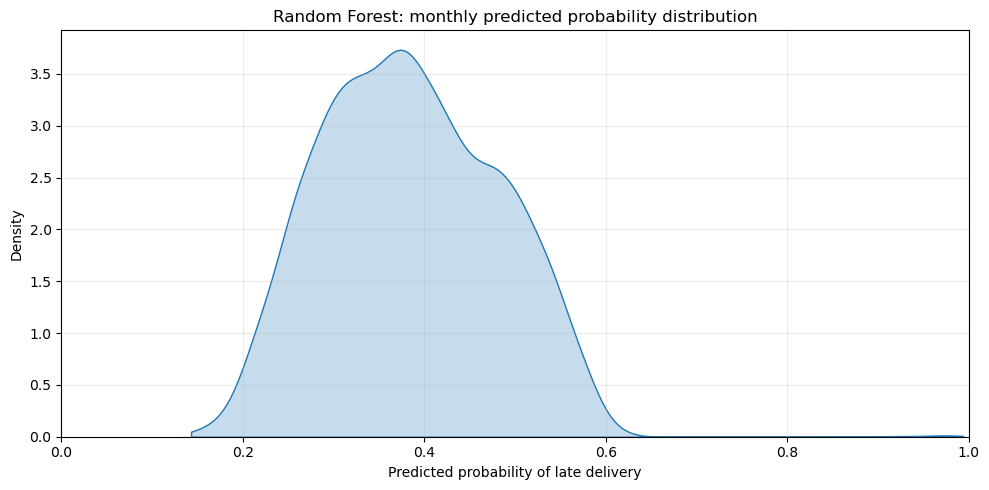

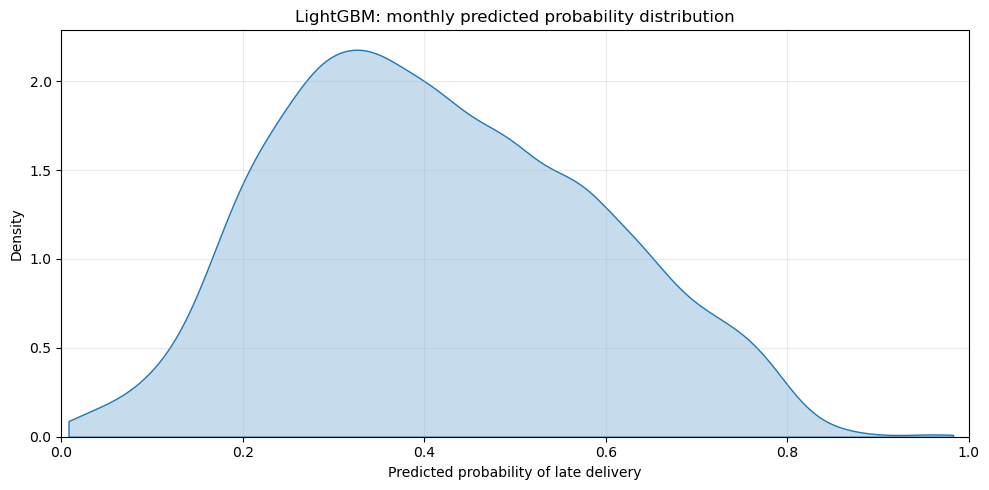

In [27]:
def inspect_prob_dist(predictions, model_name):
    # Check probability distribution by decile
    groupby_cols = ['decile']
    grouped = predictions.groupby(groupby_cols).agg(
        orders = ('order_id', 'nunique'),
        min_prob = ('predicted_probability', 'min'),
        max_prob = ('predicted_probability', 'max'),
    ).reset_index().sort_values(groupby_cols)
    # display(grouped)

    # KDE of predicted probabilities across the monthly inference cohort.
    probabilities = predictions['predicted_probability'].dropna()
    fig, ax = plt.subplots(figsize=(10, 5))
    if probabilities.nunique() > 1:
        sns.kdeplot(x=probabilities, fill=True, clip=(0, 1), cut=0, ax=ax)
    else:
        ax.text(0.5, 0.5, 'KDE requires at least two distinct probabilities.',
                ha='center', va='center', transform=ax.transAxes)
    ax.set(
        title=f'{model_name}: monthly predicted probability distribution',
        xlabel='Predicted probability of late delivery',
        ylabel='Density',
        xlim=(0, 1),
    )
    ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

inspect_prob_dist(rf_ranked_predictions, "Random Forest")
inspect_prob_dist(lgb_ranked_predictions, "LightGBM")

============================================================ End of end-to-end pipeline development  ============================================================

# Time-series cross-validation & Hyperparameter tuning
This section reuses the training window above (`train_test_label`), the same features (`FEATURE_COLS`) and the same five classifiers. Its objective is to perform cross validation using:

1. **A chronological hold-out.** The newest 30 days of the window are the test set. The random stratified split above mixes later orders into training, which can't happen in operation.
2. **Time-series CV on the remaining days.** There are 5 expanding-window folds. Each fold trains on earlier approval days and validates on later ones, with a 45-day gap. Training labels must already be known at the validation start date, and no approval day is split.

The reusable code lives in `src/tuning.py`. The tuned parameters and thresholds are saved to `results/classification_tuning.json`.

Run time is about 5 minutes on 4 cores. Every model uses `n_jobs=1`, so the parallelism happens across CV folds and the CPU isn't oversubscribed.

This section conducts time-series cross validation based on the default parameters used in the earlier section, as well as using the same run date of 2018-06-02 (i.e. June 2018 Model)

In [29]:
from sklearn.model_selection import ParameterGrid

sys.path.insert(0, os.path.abspath('.') if os.path.isdir('src') else os.path.abspath('phase2'))
from src.splits import day_blocked_time_series_folds, available_outcome_folds
from src.evaluation import classification_metrics
from src.tuning import (build_classifiers, cv_summary, tune_classifier, out_of_fold_scores,
                        best_f1_threshold, params_to_json, CLASSIFIER_SEARCH_SPACES, MODEL_FAMILY)

TUNING_TEST_DAYS = 30   # Newest approval days held out (~1 month)
N_CV_FOLDS = 5
# Random-search iterations per model; kept small for laptop run times
N_ITER = {'Logistic Regression': 12, 'Decision Tree': 15, 'Random Forest': 8,
          'XGBoost': 12, 'LightGBM': 12}

## Chronological split and CV folds
Each fold expands the earlier training period and validates on the next block of approval dates.
- Leave `LOOKBACK` (45) calendar days between training approvals and validation.
- Recheck labels as of the first validation day; exclude unknown or inconsistent training labels.
- Keep orders from the same approval day together.
- Require all five folds to contain training data; boosting fits require both classes.

### Display chronological CV folds

In [30]:
# Reusing the same splits that was created in the earlier development pipeline
cv_train_df = train_df.copy()
cv_test_df = test_df.copy()

X_cv_train, y_cv_train = X_train, y_train
X_cv_test, y_cv_test = X_test, y_test


print(f'Train: {cv_train_df["order_approved_dt"].min():%Y-%m-%d} to {cv_train_df["order_approved_dt"].max():%Y-%m-%d} '
      f'({len(cv_train_df):,} orders, {y_cv_train.mean():.2%} late)')
print(f'Test:  {cv_test_df["order_approved_dt"].min():%Y-%m-%d} to {cv_test_df["order_approved_dt"].max():%Y-%m-%d} '
      f'({len(cv_test_df):,} orders, {y_cv_test.mean():.2%} late)')

cv_folds = day_blocked_time_series_folds(
    cv_train_df['order_approved_dt'], n_splits=N_CV_FOLDS, gap_days=LOOKBACK)
cv_folds = available_outcome_folds(
    cv_train_df, cv_folds, y_cv_train, labels_as_of, 'label_as_of_run')
assert len(cv_folds) == N_CV_FOLDS
assert all(y_cv_train.iloc[tr].nunique() == 2 for tr, _ in cv_folds)
print(f'CV: {len(cv_folds)} folds with a {LOOKBACK}-day gap and known training labels')
display(pd.DataFrame([{
            'fold': k, 'train_orders': len(tr), 'valid_orders': len(va),
            'valid_from': cv_train_df['order_approved_dt'].iloc[va].min().date(),
            'valid_to': cv_train_df['order_approved_dt'].iloc[va].max().date(),
            'valid_late_rate': round(y_cv_train.iloc[va].mean() * 100, 2),
                  } for k, (tr, va) in enumerate(cv_folds, 1)]
            ).set_index('fold')
      )

Train: 2017-04-18 to 2018-03-18 (56,722 orders, 11.02% late)
Test:  2018-03-19 to 2018-04-17 (6,870 orders, 10.38% late)
CV: 5 folds with a 45-day gap and known training labels


,train_orders,valid_orders,valid_from,valid_to,valid_late_rate
fold,,,,,
1,1021,6817,2017-06-13,2017-08-07,6.29
2,7389,7876,2017-08-08,2017-10-02,6.65
3,14716,10688,2017-10-03,2017-11-27,11.51
4,22647,12024,2017-11-28,2018-01-22,9.86
5,34898,13074,2018-01-23,2018-03-18,18.53


### Build all classifiers
- Instantiate the model pipelines

In [31]:
# Boosting pipelines calculate scale_pos_weight from each fit's training labels.
default_models = build_classifiers(NUM_COLS, CAT_COLS, random_state=RANDOM_STATE)

## Cross-validated defaults
These are the settings used in the Model Training section above.
- **PR-AUC** is the primary metric. A random model scores about the late rate.
- **F1** uses the 0.5 threshold.

### Evaluation metrics from CV set

In [32]:
cv_rows = []
for name, model in default_models.items():
    cv_rows.append({'model': name, 'variant': 'default', 'family': MODEL_FAMILY[name],
                    **cv_summary(model, X_cv_train, y_cv_train, cv_folds)})
cv_results = pd.DataFrame(cv_rows).set_index(['model', 'variant'])
num_cols = cv_results.select_dtypes(include='number').columns
cv_results[num_cols] = (cv_results[num_cols] * 100).round(2)
display(cv_results)

,,family,cv_roc_auc_mean,cv_pr_auc_mean,cv_f1_at_0.5_mean
model,variant,,,,
Logistic Regression,default,Linear,54.77,14.93,16.64
Decision Tree,default,Tree-based,57.76,17.83,19.45
Random Forest,default,Tree-based,60.89,23.49,16.71
XGBoost,default,Tree-based,60.71,23.33,23.35
LightGBM,default,Tree-based,61.75,23.80,23.06


### Evaluation metrics from test set (held-out set)

In [33]:
# Refit defaults on the full training set; score only the held-out test set.
default_test_rows = []
for name, model in default_models.items():
    fitted = clone(model).fit(X_cv_train, y_cv_train)
    prob = fitted.predict_proba(X_cv_test)[:, list(fitted.classes_).index(1)]
    default_test_rows.append({
        'model': name, 'variant': 'default', 'family': MODEL_FAMILY[name],
        **classification_metrics(y_cv_test, (prob >= PREDICTION_THRESHOLD).astype(int), prob),
    })
default_test_results = pd.DataFrame(default_test_rows).set_index(['model', 'variant'])
# Display percentages, matching the CV table; retain raw metrics for reuse.
test_display = default_test_results.copy()
test_num_cols = test_display.select_dtypes(include='number').columns
test_display[test_num_cols] = (test_display[test_num_cols] * 100).round(2)
display(test_display)

,,family,roc_auc,pr_auc,accuracy,precision,recall,f1_score
model,variant,,,,,,,
Logistic Regression,default,Linear,73.20,26.39,52.26,15.51,80.93,26.03
Decision Tree,default,Tree-based,68.13,19.10,39.08,13.13,86.68,22.80
Random Forest,default,Tree-based,73.20,25.71,59.26,17.47,78.54,28.58
XGBoost,default,Tree-based,73.68,26.07,43.64,14.21,87.94,24.46
LightGBM,default,Tree-based,73.52,27.11,41.15,13.66,87.80,23.64


## Conduct hyperparameter tuning
1. **Hyperparameter tuning** with `RandomizedSearchCV` on those folds, maximising **PR-AUC** (average precision). PR-AUC suits the imbalanced late class (~13%).
2. **Threshold selection.** The threshold is chosen from out-of-fold CV scores (max F1) instead of a fixed 0.5.
3. **Default vs tuned, compared on:**
   - the hold-out;
   - a pooled monthly backtest (April–July 2018) that follows the inference flow above.

### Random search
Each model searches a small grid (`CLASSIFIER_SEARCH_SPACES` in `src/tuning.py`) on the time-series folds, maximising mean PR-AUC.
- Boosting weights are recalculated from each fit's training labels; other models retain balanced class weights. Weighting uses: `class_weight='balanced'`, or `scale_pos_weight` for the boosting models.
- The hold-out is never used for selection.

In [34]:
tuned_models, best_params = {}, {}
for name, model in default_models.items():
    n_combinations = min(N_ITER[name], len(ParameterGrid(CLASSIFIER_SEARCH_SPACES[name])))
    n_folds = len(cv_folds)
    search_fits = n_combinations * n_folds
    print(f'{name}: {n_combinations} combinations x {n_folds} folds = {search_fits} search training fits; '
          f'+ {n_folds} summary fits = {search_fits + n_folds} total fits', flush=True)
    
    tuned, params, _ = tune_classifier(model, CLASSIFIER_SEARCH_SPACES[name], X_cv_train, y_cv_train,
                                       cv_folds, n_iter=N_ITER[name], random_state=RANDOM_STATE
                                       )
    tuned_models[name], best_params[name] = tuned, params
    cv_rows.append({'model': name, 
                    'variant': 'tuned', 
                    'family': MODEL_FAMILY[name],
                    **cv_summary(tuned, X_cv_train, y_cv_train, cv_folds)
                    })
    print(f'{name}: {params_to_json(params)}')

cv_results = pd.DataFrame(cv_rows).set_index(['model', 'variant']).sort_index()
num_cols = cv_results.select_dtypes(include='number').columns
cv_results[num_cols] = (cv_results[num_cols] * 100).round(2)
display(cv_results)

cv_results_comparison = (cv_results.xs('tuned', level='variant')['cv_pr_auc_mean'] - cv_results.xs('default', level='variant')['cv_pr_auc_mean']
                         ).rename('cv_pr_auc_gain_from_tuning'
                                  ).to_frame()
display(cv_results_comparison)

Logistic Regression: 12 combinations x 5 folds = 60 search training fits; + 5 summary fits = 65 total fits
Logistic Regression: {'classifier__C': 10000.0}
Decision Tree: 15 combinations x 5 folds = 75 search training fits; + 5 summary fits = 80 total fits
Decision Tree: {'classifier__min_samples_leaf': 50, 'classifier__max_depth': 10, 'classifier__criterion': 'gini'}
Random Forest: 8 combinations x 5 folds = 40 search training fits; + 5 summary fits = 45 total fits
Random Forest: {'classifier__n_estimators': 200, 'classifier__min_samples_leaf': 1, 'classifier__max_features': 'sqrt', 'classifier__max_depth': 12}
XGBoost: 12 combinations x 5 folds = 60 search training fits; + 5 summary fits = 65 total fits
XGBoost: {'classifier__subsample': 0.7, 'classifier__n_estimators': 400, 'classifier__min_child_weight': 5, 'classifier__max_depth': 8, 'classifier__learning_rate': 0.01, 'classifier__colsample_bytree': 1.0}
LightGBM: 12 combinations x 5 folds = 60 search training fits; + 5 summary fit

family  cv_roc_auc_mean  cv_pr_auc_mean  \
model               variant                                                
Decision Tree       default  Tree-based            57.76           17.83   
                    tuned    Tree-based            58.48           19.85   
LightGBM            default  Tree-based            61.75           23.80   
                    tuned    Tree-based            62.02           25.16   
Logistic Regression default      Linear            54.77           14.93   
                    tuned        Linear            55.52           19.73   
Random Forest       default  Tree-based            60.89           23.49   
                    tuned    Tree-based            61.79           24.27   
XGBoost             default  Tree-based            60.71           23.33   
                    tuned    Tree-based            62.54           24.62   

                             cv_f1_at_0.5_mean  
model               variant                     
Decision Tree       default              19.45  
                    tuned                19.99  
LightGBM            default              23.06  
                    tuned                24.18  
Logistic Regression default              16.64  
                    tuned                20.26  
Random Forest       default              16.71  
                    tuned                13.91  
XGBoost             default              23.35  
                    tuned                23.49

,cv_pr_auc_gain_from_tuning
model,
Decision Tree,2.02
LightGBM,1.36
Logistic Regression,4.80
Random Forest,0.78
XGBoost,1.29


### Threshold selection
For each tuned model, this picks the threshold that maximises F1 on the **out-of-fold** CV scores. Each score comes from a model that never saw that order.

In [35]:
tuned_thresholds = {}
for name, model in tuned_models.items():
    oof = out_of_fold_scores(model, X_cv_train, y_cv_train, cv_folds)
    tuned_thresholds[name], oof_f1 = best_f1_threshold(y_cv_train, oof)
    print(f'{name}: threshold {tuned_thresholds[name]:.3f} (out-of-fold F1 {oof_f1:.3f})')

Logistic Regression: threshold 0.608 (out-of-fold F1 0.239)
Decision Tree: threshold 0.761 (out-of-fold F1 0.273)
Random Forest: threshold 0.330 (out-of-fold F1 0.317)
XGBoost: threshold 0.515 (out-of-fold F1 0.317)
LightGBM: threshold 0.553 (out-of-fold F1 0.305)


### Hold-out evaluation (newest 30 days of the window)

In [36]:
holdout_rows = []
for variant, model_set in [('default', default_models), ('tuned', tuned_models)]:
    for name, model in model_set.items():
        fitted = clone(model).fit(X_cv_train, y_cv_train)
        prob = fitted.predict_proba(X_cv_test)[:, list(fitted.classes_).index(1)]
        cutoffs = [0.5] + ([tuned_thresholds[name]] if variant == 'tuned' else [])
        for cutoff in cutoffs:
            holdout_rows.append({'model': name, 'variant': variant, 'threshold': cutoff,
                                 'flagged_pct': (prob >= cutoff).mean(),
                                 **classification_metrics(y_cv_test, (prob >= cutoff).astype(int), prob)})

holdout_results = pd.DataFrame(holdout_rows).set_index(['model', 'variant', 'threshold'])
display(holdout_results.style.format('{:.2%}', na_rep='N/A'))


# Use best-performing model for prediction
This section selects the best-performing model to predict on the inference set and obtain the final evaluation results
- Select one model/variant by the highest **hold-out PR-AUC**, breaking ties by **F1**, then ROC-AUC. 
- Use default threshold of 0.5 since the tuned thresholds do not improve F1 score in the test (hold-out) set

Refit the selected pipeline on all known labels in `train_test_label`, available before `run_date`. 
- Keep its hyperparameters, threshold and fitted preprocessing fixed throughout the inference month
- Score each day's eligible orders, pool the daily predictions, and evaluate outcomes at each approval day's inclusive `LOOKBACK` cutoff using the same rules as **Backtesting - Inference Set**


In [37]:
# Select from raw hold-out metrics, without using inference outcomes.
selection_candidates = holdout_results.reset_index().copy()
selection_candidates['deployment_threshold'] = 0.5

# Tuned models were evaluated at both 0.5 and their OOF threshold. Keep only
# the CV-selected threshold, so hold-out outcomes do not tune the threshold.
selection_candidates = selection_candidates.loc[np.isclose(
    selection_candidates['threshold'], selection_candidates['deployment_threshold'],
    rtol=0, atol=1e-12,
)].drop_duplicates(['model', 'variant'])
selection_candidates = selection_candidates.dropna(subset=['pr_auc']).sort_values(
    ['pr_auc', 'f1_score', 'roc_auc', 'model', 'variant'],
    ascending=[False, False, False, True, True], kind='stable',
).reset_index(drop=True)
if selection_candidates.empty:
    raise ValueError('No valid hold-out PR-AUC: check that the hold-out contains both classes.')

best_model_result = selection_candidates.iloc[0]
best_model_name = best_model_result['model']
best_model_variant = best_model_result['variant']
best_model_threshold = float(best_model_result['deployment_threshold'])
best_model_template = (tuned_models if best_model_variant == 'tuned' else default_models)[best_model_name]

best_model_description = f'{best_model_name} ({best_model_variant})'
print(f'Selected {best_model_description}: hold-out PR-AUC '
      f'{best_model_result["pr_auc"]:.4f}, F1 {best_model_result["f1_score"]:.4f}; '
      f'prediction threshold {best_model_threshold:.4f}')
display(selection_candidates.drop(columns='deployment_threshold').style.format({
    'threshold': '{:.4f}', **{column: '{:.2%}' for column in holdout_results.columns},
}, na_rep='N/A'))

Selected Logistic Regression (tuned): hold-out PR-AUC 0.2820, F1 0.2666; prediction threshold 0.5000


,model,variant,threshold,flagged_pct,roc_auc,pr_auc,accuracy,precision,recall,f1_score
0,Logistic Regression,tuned,0.5000,50.66%,74.17%,28.20%,55.24%,16.06%,78.40%,26.66%
1,LightGBM,tuned,0.5000,69.33%,74.35%,27.72%,38.95%,13.46%,89.90%,23.41%
2,LightGBM,default,0.5000,66.70%,73.52%,27.11%,41.15%,13.66%,87.80%,23.64%
3,XGBoost,tuned,0.5000,61.08%,73.99%,26.58%,46.27%,14.51%,85.41%,24.81%
4,Logistic Regression,default,0.5000,54.16%,73.20%,26.39%,52.26%,15.51%,80.93%,26.03%
5,XGBoost,default,0.5000,64.24%,73.68%,26.07%,43.64%,14.21%,87.94%,24.46%
6,Random Forest,default,0.5000,46.67%,73.20%,25.71%,59.26%,17.47%,78.54%,28.58%
7,Random Forest,tuned,0.5000,39.64%,72.99%,25.28%,65.07%,19.02%,72.65%,30.15%
8,Decision Tree,tuned,0.5000,68.95%,68.50%,20.97%,38.43%,12.88%,85.55%,22.39%
9,Decision Tree,default,0.5000,68.53%,68.13%,19.10%,39.08%,13.13%,86.68%,22.80%


In [38]:
# Selection is complete: include the hold-out in the final historical refit.
# No orders from the recent buffer or inference month are fitted.
best_model_pipeline = clone(best_model_template).fit(
    train_test_label[FEATURE_COLS], train_test_label[LABEL_COL],
)
print(f'Refitted on {len(train_test_label):,} orders with labels known before {run_date}.')

Refitted on 63,592 orders with labels known before 2018-06-02.


In [39]:
# Use the same fitted model for every daily cohort in this run's month.
best_inference_start_date, best_inference_end_date = get_month_start_end(run_date)

# Run daily predictions using the selected model
best_inference_predictions = run_inference(
    best_inference_start_date, best_inference_end_date, best_model_pipeline,
)

# Retrieve actual labels for each order
best_inference_predictions = attach_prediction_labels(
    best_inference_predictions, lookback=LOOKBACK,
    prediction_threshold=best_model_threshold, model_name=best_model_description,
)

# Retain model provenance alongside each saved daily score.
best_inference_predictions['model'] = best_model_name
best_inference_predictions['variant'] = best_model_variant
best_inference_predictions['model_run_date'] = run_date
best_inference_predictions['prediction_threshold'] = best_model_threshold

best_daily_prediction_summary = best_inference_predictions.groupby('order_approved_dt').agg(
        orders=('order_id', 'size'),
        flagged_orders=('predicted_label', 'sum'),
        known_labels=('actual_label', 'count'),
    ).reindex(pd.date_range(best_inference_start_date, best_inference_end_date), fill_value=0)

best_daily_prediction_summary.index.name = 'inference_date'
best_daily_prediction_summary['unknown_labels'] = (
        best_daily_prediction_summary['orders'] - best_daily_prediction_summary['known_labels']
    )
display(best_inference_predictions.head())

LogisticRegression predictions: 
6,164 orders between 2018-06-01 and 2018-06-30 (inclusive), across 30 days with eligible orders

Logistic Regression (tuned): known actual labels at approval day + 45 days: 6,155/6,164 (99.85%)
PASS: inference label availability versus 99% historical target.


,order_approved_dt,order_id,predicted_probability,actual_label,label_status,evaluation_cutoff,predicted_label,model,variant,model_run_date,prediction_threshold
0,2018-06-01,00c763284c0056eed753352f5559ff0a,0.15,0,on_time_delivered,2018-07-16,0,Logistic Regression,tuned,2018-06-02,0.50
1,2018-06-01,022d4b171a04520ca2113a48b6b61380,0.12,0,on_time_delivered,2018-07-16,0,Logistic Regression,tuned,2018-06-02,0.50
2,2018-06-01,025a548c7e6d70e6b6cf600a112b0d9c,0.21,0,on_time_delivered,2018-07-16,0,Logistic Regression,tuned,2018-06-02,0.50
3,2018-06-01,038b8c914a94247880b6a34413e74a34,0.19,0,on_time_delivered,2018-07-16,0,Logistic Regression,tuned,2018-06-02,0.50
4,2018-06-01,05bdb94211a1ae1e3734545262f50da3,0.18,0,on_time_delivered,2018-07-16,0,Logistic Regression,tuned,2018-06-02,0.50


In [40]:
# Compute metrics once on all pooled daily predictions, rather than averaging
# daily metrics. Unknown actual labels are reported and excluded by the helper.
best_inference_metrics = evaluate_monthly_predictions(
    best_inference_predictions, best_model_description,
)
print(f'Pooled inference evaluation: {best_inference_start_date} to {best_inference_end_date}')
display(best_inference_metrics.style.format('{:.2%}', na_rep='N/A'))

# Rank the whole monthly cohort together, using the same decile definitions
# and unknown-label handling as the earlier inference backtest.
best_inference_coverage, best_ranked_predictions = display_decile_coverage(
    best_inference_predictions, best_model_description,
)


Logistic Regression (tuned): evaluated 6,155 orders; excluded 9 unknown outcomes.
Pooled inference evaluation: 2018-06-01 to 2018-06-30


,roc_auc,pr_auc,accuracy,precision,recall,f1_score
model,,,,,,
Logistic Regression (tuned),71.76%,12.18%,85.90%,6.54%,40.15%,11.25%


Logistic Regression (tuned): monthly decile coverage


,decile,number_of_orders,known_labels,positive_labels,unknown_labels,cumulative_orders,cumulative_known_labels,cumulative_positive_labels,late_delivery_rate,cumulative_late_delivery_rate,coverage
0,1,617,616,46,1,617,616,46,7.47%,7.47%,33.58%
1,2,616,616,21,0,1233,1232,67,3.41%,5.44%,48.91%
2,3,616,615,14,1,1849,1847,81,2.28%,4.39%,59.12%
3,4,617,616,13,1,2466,2463,94,2.11%,3.82%,68.61%
4,5,616,616,11,0,3082,3079,105,1.79%,3.41%,76.64%
5,6,616,614,11,2,3698,3693,116,1.79%,3.14%,84.67%
6,7,617,617,4,0,4315,4310,120,0.65%,2.78%,87.59%
7,8,616,615,8,1,4931,4925,128,1.30%,2.60%,93.43%
8,9,616,614,8,2,5547,5539,136,1.30%,2.46%,99.27%
9,10,617,616,1,1,6164,6155,137,0.16%,2.23%,100.00%
